# Credit Card Fraud Detection using Machine Learning

This project aims to detect fraudulent credit card transactions using machine learning techniques.
Fraud detection is challenging due to the highly imbalanced nature of the dataset where fraudulent
transactions represent a very small percentage of the total data.

In this project we:

• Perform exploratory data analysis  
• Train Logistic Regression as a baseline model  
• Train Random Forest for improved performance  
• Perform hyperparameter tuning using RandomizedSearchCV  
• Evaluate models using Precision, Recall, F1-score and ROC-AUC  
• Compare models and interpret results from a business perspective

## Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,matthews_corrcoef,roc_auc_score,roc_curve

## Loading the Dataset

In [ ]:
data = pd.read_csv("creditcard.csv")
print(data.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

We separate the dataset into two groups : Fraudulent(Class=1) and Valid Transactions(Class=0). This calculates the ratio of fraud cases to valid cases to measure how imbalanced the dataset is.

## Exploratory Data Analysis

Understanding the imbalance in dataset.

In [ ]:
fraud = data[data['Class'] == 1]
valid = data[data['Class'] == 0]
outlierFraction = len(fraud)/float(len(valid))
print(outlierFraction)
print('Fraud Cases: {}'.format(len(data[data['Class'] == 1])))
print('Valid transactions: {}'.format(len(data[data['Class'] == 0])))

0.0017304750013189597
Fraud Cases: 492
Valid transactions: 284315


In [ ]:
print("Amount details of the fraudulent transaction")
fraud.Amount.describe()

Amount details of the fraudulent transaction


,Amount
count,492.000000
mean,122.211321
std,256.683288
min,0.000000
25%,1.000000
50%,9.250000
75%,105.890000
max,2125.870000


In [ ]:
print("Amount details of valid transaction")
valid.Amount.describe()

Amount details of valid transaction


,Amount
count,284315.000000
mean,88.291022
std,250.105092
min,0.000000
25%,5.650000
50%,22.000000
75%,77.050000
max,25691.160000


By exploring the transaction amounts, we observe tha fraudulent transactions tend to have higher average amounts which is important in fraud detection.

## Data Preparation

Separating features and target variable and performing train-test split.

In [ ]:
X = data.drop(['Class'],axis=1)
Y = data['Class']

xTrain,xTest,yTrain,yTest = train_test_split(X,Y,test_size = 0.2,stratify = Y,random_state=42)

Because the dataset is highly imbalanced, we use stratified sampling.
This ensures that both training and testing datasets maintain the same
fraud-to-normal transaction ratio.

## Class Distribution


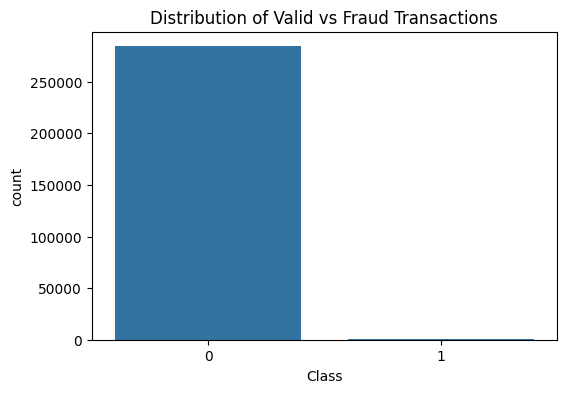

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=data)
plt.title("Distribution of Valid vs Fraud Transactions")
plt.show()

## **Model 1 : Logistic Regression**

Logistic regression is used as a baseline model because it is simple,
interpretable, and commonly used for binary classification tasks.

In [ ]:
log_model = LogisticRegression(max_iter=1000,class_weight='balanced')
log_model.fit(xTrain,yTrain)

log_pred = log_model.predict(xTest)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Logistic Regression Evaluation

Model Evaluation Metrics:
Accuracy: 0.9702
Precision: 0.0506
Recall: 0.9184
F1-Score: 0.0960
Matthews Correlation Coefficient: 0.2119


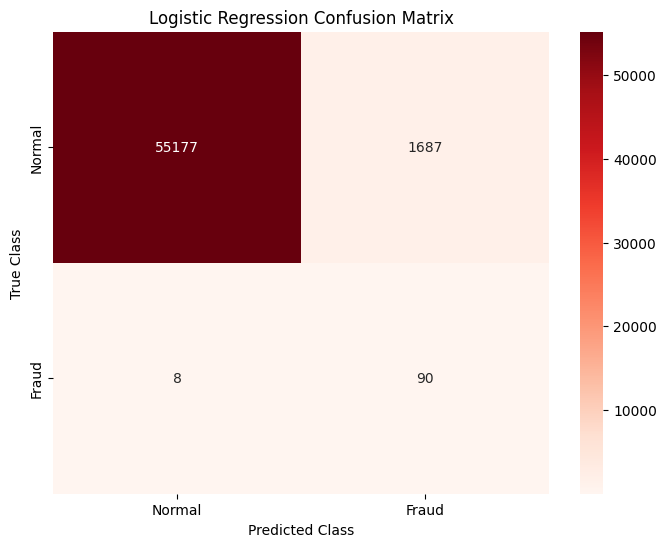

In [ ]:
log_accuracy = accuracy_score(yTest, log_pred)
log_precision = precision_score(yTest, log_pred)
log_recall = recall_score(yTest, log_pred)
log_f1 = f1_score(yTest, log_pred)
log_mcc = matthews_corrcoef(yTest, log_pred)

print("Model Evaluation Metrics:")
print(f"Accuracy: {log_accuracy:.4f}")
print(f"Precision: {log_precision:.4f}")
print(f"Recall: {log_recall:.4f}")
print(f"F1-Score: {log_f1:.4f}")
print(f"Matthews Correlation Coefficient: {log_mcc:.4f}")

conf_matrix = confusion_matrix(yTest, log_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Reds",
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

In [ ]:
log_probs = log_model.predict_proba(xTest)[:,1]
log_auc = roc_auc_score(yTest, log_probs)

print("Logistic Regression ROC-AUC:", log_auc)

Logistic Regression ROC-AUC: 0.9727243053242681


Logistic Regression is used as a baseline model because it is simple and interpretable.

However, due to the complex nature of fraud detection patterns, ensemble methods like Random Forest may capture nonlinear relationships better.

## **Model 2 : Random Forest**

Random Forest is an ensemble learning algorithm that combines multiple
decision trees to improve predictive performance and reduce overfitting.

In [ ]:
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(class_weight='balanced', random_state=42)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_grid,
    n_iter=5,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(xTrain, yTrain)

print(random_search.best_estimator_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
RandomForestClassifier(class_weight='balanced', min_samples_split=5,
                       random_state=42)


In [ ]:
rf = RandomForestClassifier(n_estimators = 200,
                            class_weight='balanced',
                            min_samples_split=5,
                            random_state=42)
rf.fit(xTrain,yTrain)
yPred = rf.predict(xTest)

## Random Forest Evaluation


Model Evaluation Metrics:
Accuracy: 0.9995
Precision: 0.9610
Recall: 0.7551
F1-Score: 0.8457
Matthews Correlation Coefficient: 0.8517


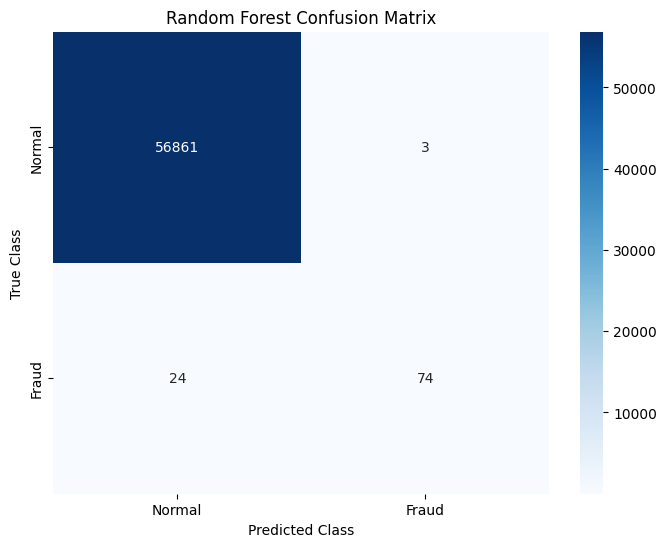

In [ ]:
rf_accuracy = accuracy_score(yTest, yPred)
rf_precision = precision_score(yTest, yPred)
rf_recall = recall_score(yTest, yPred)
rf_f1 = f1_score(yTest, yPred)
rf_mcc = matthews_corrcoef(yTest, yPred)

print("Model Evaluation Metrics:")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1-Score: {rf_f1:.4f}")
print(f"Matthews Correlation Coefficient: {rf_mcc:.4f}")

conf_matrix = confusion_matrix(yTest, yPred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

In [ ]:
rf_probs = rf.predict_proba(xTest)[:,1]
rf_auc = roc_auc_score(yTest, rf_probs)

print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.956564642598739


## ROC Curve Comparison

The ROC curve shows the tradeoff between True Positive Rate (Recall)
and False Positive Rate. A higher Area Under Curve (AUC) indicates
better ability to distinguish between fraud and normal transactions.

In [ ]:
log_fpr, log_tpr, _ = roc_curve(yTest, log_probs)
rf_fpr, rf_tpr, _ = roc_curve(yTest, rf_probs)

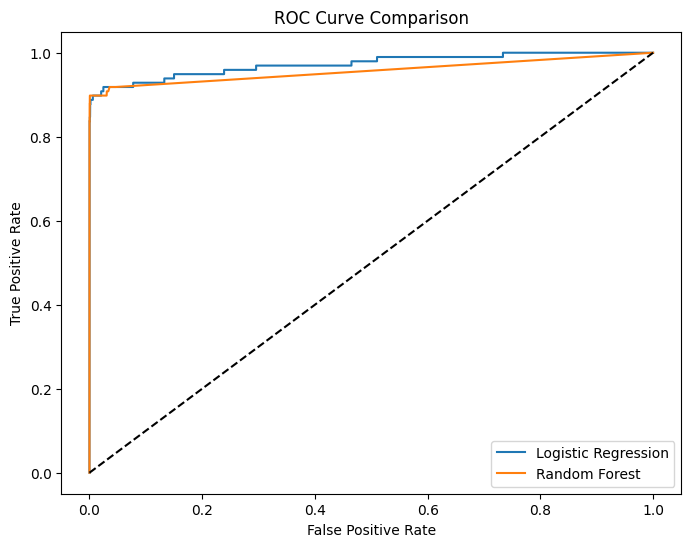

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(log_fpr, log_tpr, label="Logistic Regression")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()
plt.savefig("roc_curve.png")

## Feature Importance

Random Forest provides feature importance scores which indicate which
variables contribute the most to the prediction.

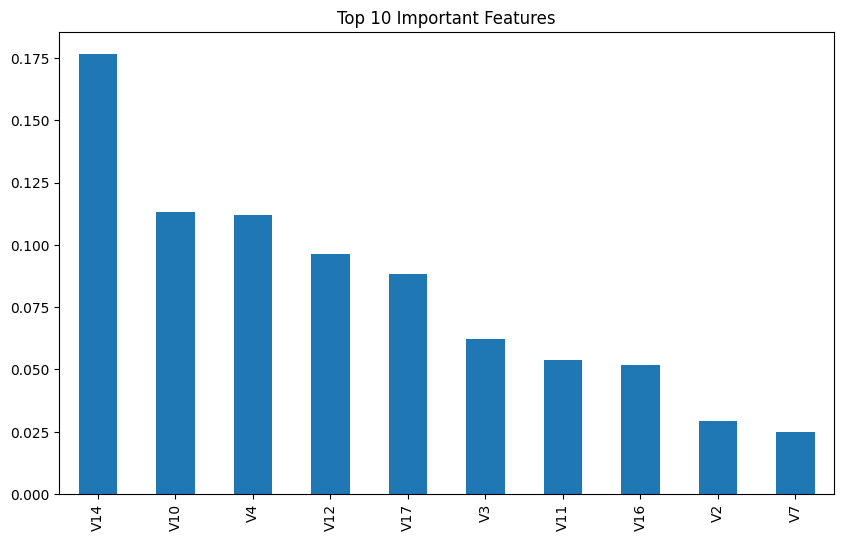

In [ ]:
importances = rf.feature_importances_

feature_importance = pd.Series(importances, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

## Model Comparison

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Precision": [log_precision, rf_precision],
    "Recall": [log_recall, rf_recall],
    "F1 Score": [log_f1, rf_f1],
    "ROC-AUC": [log_auc, rf_auc]
})

comparison

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.050647,0.918367,0.096000,0.972724
1,Random Forest,0.961039,0.755102,0.845714,0.956565


In a fraud detection system, recall is extremely important because missing
fraudulent transactions can lead to financial losses.

Random Forest achieved higher recall compared to Logistic Regression,
indicating better detection of fraudulent transactions.

Therefore Random Forest is the preferred model for this task.